# Tutorial: Gradient-Based Hull Shape Optimization for AquaHarmonics

This tutorial demonstrates **hull shape optimization** for the AquaHarmonics WEC using a hybrid gradient approach, with the objective of maximizing **electrical power per unit hull volume** (power density, W/m³).

- **Inner loop**: IPOPT solves for optimal WEC control (given BEM coefficients)
- **Outer loop**: gradient-based optimizer adjusts hull shape parameters to maximize power density

The gradient of power density w.r.t. shape is computed via the **chain rule** and **quotient rule**:

$$J(\theta) = \frac{\varphi^*(\theta)}{V(\theta)}, \qquad
\frac{dJ}{d\theta} = \frac{1}{V}\frac{d\varphi^*}{d\theta} - \frac{\varphi^*}{V^2}\frac{dV}{d\theta}$$

where:
- $d\varphi^*/d\theta$ uses the hybrid gradient: Fiacco sensitivity + FD through Capytaine
- $dV/d\theta$ is computed **analytically** from the hull geometry (trivial)
- $\theta$ are the hull shape parameters (radii, drafts)

### Table of Contents

1. [Setup](#1.-Setup) -- PTO, forces, constraints, wave conditions
2. [Baseline](#2.-Baseline) -- solve at default shape, compute Fiacco sensitivity
3. [Shape-to-BEM Pipeline](#3.-Shape-to-BEM-Pipeline) -- function from shape params to BEM data
4. [Hybrid Gradient](#4.-Hybrid-Gradient) -- FD through Capytaine + analytical Fiacco
5. [Optimization](#5.-Optimization) -- maximize power density via `scipy.optimize.minimize`
6. [Results](#6.-Results) -- compare initial vs. optimized hull

## 1. Setup

We reuse the AquaHarmonics PTO, forces, and constraints from [Tutorial 2](../examples/tutorial_2_AquaHarmonics.ipynb). The only difference is that the hull geometry is now **parameterized** — we will vary `r1` (main cylinder radius) and `T1` (draft) during optimization.

In [1]:
import capytaine as cpy
from capytaine.io.meshio import load_from_meshio
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.optimize import minimize

import wecopttool as wot
from wecopttool_differentiable import (
    WEC_IPOPT,
    sensitivity,
    BEMParams,
    extract_bem_params,
    extract_wave_data,
    plot_sensitivity_bars,
)

plt.style.use('tableau-colorblind10')
cc = plt.rcParams['axes.prop_cycle'].by_key()['color']

### Shape parameters

We optimize two hull dimensions that strongly affect the heave response:
- `r1`: radius of the main (upper) cylinder [m]
- `T1`: draft of the main cylinder [m]

The remaining dimensions (`T2`, `T3`, `r2`, `r3`) are held fixed.

In [2]:
# Shape parameter names and defaults
SHAPE_NAMES = ['r1', 'T1']
SHAPE_DEFAULTS = {'r1': 1.085, 'T1': 1.5}

# Fixed geometry
FIXED_GEOM = {'T2': 0.355, 'T3': 7.25, 'r2': 0.405, 'r3': 0.355}

# Bounds for optimization (physical constraints)
SHAPE_BOUNDS = {
    'r1': (0.5, 2.5),   # radius: 0.5m to 2.5m
    'T1': (0.5, 3.0),   # draft: 0.5m to 3.0m
}


def hull_volume(r1, T1, T2=FIXED_GEOM['T2'], T3=FIXED_GEOM['T3'],
                r2=FIXED_GEOM['r2'], r3=FIXED_GEOM['r3']):
    """Compute submerged hull volume [m^3].

    AquaHarmonics geometry:
      - Upper cylinder:  V = pi r1^2 T1
      - Conical frustum: V = (pi T2 / 3)(r1^2 + r1 r2 + r2^2)
      - Hollow tube:     V = pi (r2^2 - r3^2) T3
    """
    V_cyl = np.pi * r1**2 * T1
    V_cone = (np.pi * T2 / 3) * (r1**2 + r1 * r2 + r2**2)
    V_tube = np.pi * (r2**2 - r3**2) * T3
    return V_cyl + V_cone + V_tube


def hull_volume_gradient(r1, T1, T2=FIXED_GEOM['T2'],
                         r2=FIXED_GEOM['r2']):
    """Analytical gradient dV/d(r1, T1).

    dV/dr1 = 2 pi r1 T1 + (pi T2/3)(2 r1 + r2)
    dV/dT1 = pi r1^2
    """
    dV_dr1 = 2 * np.pi * r1 * T1 + (np.pi * T2 / 3) * (2 * r1 + r2)
    dV_dT1 = np.pi * r1**2
    return {'r1': dV_dr1, 'T1': dV_dT1}


V_default = hull_volume(**SHAPE_DEFAULTS)

print('Shape parameters to optimize:')
for name in SHAPE_NAMES:
    lo, hi = SHAPE_BOUNDS[name]
    print(f'  {name}: default={SHAPE_DEFAULTS[name]:.3f}m, bounds=[{lo}, {hi}]m')
print(f'\nHull volume at default shape: {V_default:.3f} m\u00b3')

Shape parameters to optimize:
  r1: default=1.085m, bounds=[0.5, 2.5]m
  T1: default=1.500m, bounds=[0.5, 3.0]m

Hull volume at default shape: 7.075 m³


### Wave conditions

In [3]:
amplitude = 0.5
wavefreq = 0.24 / 2
phase = 30
wavedir = 0

f1 = wavefreq
nfreq = 10
ndof = 1

waves = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)
freq = wot.frequency(f1, nfreq, False)

print(f"f1 = {f1} Hz, nfreq = {nfreq}")
print(f"Wave: A={amplitude}m, f={wavefreq}Hz")

f1 = 0.12 Hz, nfreq = 10
Wave: A=0.5m, f=0.12Hz


### PTO, forces, and constraints

These are identical to Tutorial 2. The PTO, drive train, generator loss map, buoyancy, gravity, and constraints do **not** depend on the hull shape parameters.

In [4]:
# ── Drive train parameters ──────────────────────────────────────────
radii = {
    "S1": 0.02, "S2": 0.795, "S3": 0.1595, "S4": 0.200525, "S5": 0.40105,
    "S6": 0.12575, "S7": 0.103
}
inertias = {
    "Igen": 3.9, "I1": 0.029, "I2": 25.6, "I3": 1.43, "I4": 1.165, "I5": 4.99,
    "I6": 1.43, "I7": 1.5, "mps": 40
}
friction_coeffs = {
    "Bgen": 7, "Bdrivetrain": 40, "Bshaft": 40, "Bspring_pulley": 80,
    "Bpneumatic_spring": 700, "Bpneumatic_spring_static1": 0,
    "Bpspneumatic_spring_static2": 0
}
airspring = {
    "gamma": 1.4, "height": 1, "diameter": 3, "area": 0.0709676,
    "press_init": 854e3, "vol_init": 1
}

gear_ratios = {
    "R21": radii['S2'] / radii['S1'],
    "R45": radii['S4'] / radii['S5'],
    "R67": radii['S6'] / radii['S7'],
    "spring": radii['S6'] * (radii['S4'] / radii['S5'])
}

inertia_pto = (
    (inertias["Igen"] + inertias["I1"]) * gear_ratios['R21']**2 +
    (inertias['I2'] + inertias['I3'] + inertias['I4']) +
    gear_ratios["R45"]**2 * (
        inertias['I5'] + inertias['I6'] +
        inertias["I7"] * gear_ratios['R67']**2 +
        inertias['mps'] * radii['S6']**2
    )
)

friction_pto = (
    friction_coeffs['Bgen'] * gear_ratios['R21']**2 +
    friction_coeffs['Bdrivetrain'] +
    gear_ratios["R45"]**2 * (
        friction_coeffs["Bshaft"] +
        friction_coeffs["Bspring_pulley"] * gear_ratios['R67']**2 +
        friction_coeffs["Bpneumatic_spring"] * radii['S6']**2
    )
)

def power_loss(speed, torque):
    winding_resistance = 0.4
    torque_coefficient = 1.5
    return winding_resistance * (torque / torque_coefficient)**2

# ── PTO object ─────────────────────────────────────────────────────
gear_ratio_generator = gear_ratios['R21'] / radii['S3']
kinematics = gear_ratio_generator * np.eye(ndof)
controller = wot.controllers.unstructured_controller()
nstate_opt = 2 * nfreq
pto = wot.pto.PTO(
    ndof, kinematics, controller, None, power_loss, ["PTO_Heave"]
)

print(f"PTO: gear_ratio_generator = {gear_ratio_generator:.2f}")
print(f"nstate_opt = {nstate_opt}")

PTO: gear_ratio_generator = 249.22
nstate_opt = 20


In [5]:
# ── Additional forces ──────────────────────────────────────────────
g_acc = 9.81
rho = 1025

def make_forces_and_constraints(displacement):
    """Create force functions and constraints.

    `displacement` depends on the hull shape (via buoyancy), so we
    rebuild these closures for each new geometry.
    """
    def f_buoyancy(wec, x_wec, x_opt, wave, nsubsteps=1):
        return displacement * rho * g_acc * jnp.ones(
            [wec.ncomponents * nsubsteps, wec.ndof])

    def f_gravity(wec, x_wec, x_opt, wave, nsubsteps=1):
        return -1 * wec.inertia_matrix.item() * g_acc * jnp.ones(
            [wec.ncomponents * nsubsteps, wec.ndof])

    def f_pretension_wec(wec, x_wec, x_opt, wave, nsubsteps=1):
        return -1 * (f_buoyancy(wec, x_wec, x_opt, wave, nsubsteps)
                     + f_gravity(wec, x_wec, x_opt, wave, nsubsteps))

    def f_pto_passive(wec, x_wec, x_opt, wave, nsubsteps=1):
        pos = wec.vec_to_dofmat(x_wec)
        vel = jnp.dot(wec.derivative_mat, pos)
        acc = jnp.dot(wec.derivative_mat, vel)
        time_matrix = wec.time_mat_nsubsteps(nsubsteps)
        spring = -(gear_ratios['spring'] * airspring['gamma']
                   * airspring['area'] * airspring['press_init']
                   / airspring['vol_init']) * pos
        fric = -(friction_pto + friction_coeffs['Bpneumatic_spring_static1']
                 * gear_ratios['spring']) * vel
        return (jnp.dot(time_matrix, spring)
                + jnp.dot(time_matrix, fric)
                + jnp.dot(time_matrix, inertia_pto * acc))

    def f_pto_line(wec, x_wec, x_opt, wave, nsubsteps=1):
        return (pto.force_on_wec(wec, x_wec, x_opt, wave, nsubsteps)
                + f_pretension_wec(wec, x_wec, x_opt, wave, nsubsteps))

    f_add = {
        'PTO': f_pto_line, 'PTO_passive': f_pto_passive,
        'buoyancy': f_buoyancy, 'gravity': f_gravity,
    }

    # Constraints
    torque_peak_max, power_max = 280, 80e3
    rot_speed_max = 10000 * 2 * np.pi / 60
    min_line_tension = -1000
    nsubsteps = 2

    constraints = [
        {'type': 'ineq', 'fun': lambda wec, xw, xo, w:
            -1 * f_pto_line(wec, xw, xo, w, nsubsteps).flatten() + min_line_tension},
        {'type': 'ineq', 'fun': lambda wec, xw, xo, w:
            torque_peak_max - jnp.abs(pto.force(wec, xw, xo, w, nsubsteps).flatten())},
        {'type': 'ineq', 'fun': lambda wec, xw, xo, w:
            rot_speed_max - jnp.abs(pto.velocity(wec, xw, xo, w, nsubsteps).flatten())},
        {'type': 'ineq', 'fun': lambda wec, xw, xo, w:
            power_max - jnp.abs((pto.velocity(wec, xw, xo, w, nsubsteps)
                                 * pto.force(wec, xw, xo, w, nsubsteps)).flatten())},
        {'type': 'eq', 'fun': lambda wec, xw, xo, w: xw[0]},
    ]

    return f_add, constraints

print("Force and constraint factory defined.")

Force and constraint factory defined.


## 2. Baseline

Solve at the default hull shape to establish the baseline optimal power, power density, and Fiacco sensitivity.

In [6]:
# ── Build and solve at default shape ───────────────────────────────
def build_wec_from_shape(r1, T1):
    """Mesh -> BEM -> WEC_IPOPT for given shape parameters."""
    hull = wot.geom.AquaHarmonics(r1=r1, T1=T1, **FIXED_GEOM)
    mesh = hull.mesh(mesh_size_factor=0.25)

    mesh_obj = load_from_meshio(mesh, 'AquaHarmonics')
    lid_mesh = mesh_obj.generate_lid(-5e-2)
    fb = cpy.FloatingBody(mesh=mesh_obj, lid_mesh=lid_mesh,
                          name="AquaHarmonics")
    fb.add_translation_dof(name="Heave")

    fb.center_of_mass = [0, 0, 0]
    fb.rotation_center = fb.center_of_mass
    displaced_mass = fb.compute_rigid_body_inertia(rho=rho).values
    displacement = displaced_mass / rho
    fb.mass = np.atleast_2d(5e3)

    bem_data = wot.run_bem(fb, freq, rho=rho, g=g_acc)
    f_add, cons = make_forces_and_constraints(displacement)

    wec = WEC_IPOPT.from_bem(bem_data, constraints=cons, f_add=f_add)
    return wec, bem_data, displacement

print("build_wec_from_shape() defined.")

build_wec_from_shape() defined.


In [7]:
# Solve baseline
wec_base, bem_base, disp_base = build_wec_from_shape(**SHAPE_DEFAULTS)

scale_x_wec = 1e1
scale_x_opt = 50e-2
scale_obj = 1e-3

solve_kw = dict(
    x_wec_0=np.ones(wec_base.nstate_wec) * 1e-3,
    x_opt_0=np.ones(nstate_opt) * 1e-3,
    scale_x_wec=scale_x_wec,
    scale_x_opt=scale_x_opt,
    scale_obj=scale_obj,
    optim_options={'max_iter': 2000, 'tol': 1e-8, 'print_level': 0},
)

res_base = wec_base.solve(waves, pto.average_power, nstate_opt, **solve_kw)[0]
phi_base = res_base.fun
V_base = hull_volume(**SHAPE_DEFAULTS)
pd_base = phi_base / V_base   # power density [W/m^3]

print(f'Baseline shape:    r1={SHAPE_DEFAULTS["r1"]:.3f}m, T1={SHAPE_DEFAULTS["T1"]:.3f}m')
print(f'Hull volume:       {V_base:.3f} m\u00b3')
print(f'Baseline power:    {phi_base/1e3:.2f} kW')
print(f'Power density:     {pd_base:.2f} W/m\u00b3')

Info    : [  0%] Difference                                                                                  
Info    : [ 10%] Difference                                                                                  
Info    : [ 20%] Difference                                                                                  
Info    : [ 30%] Difference                                                                                  
Info    : [ 40%] Difference                                                                                  
Info    : [ 50%] Difference                                                                                  
Info    : [ 60%] Difference                                                                                  
Info    : [ 70%] Difference - Filling splits of edges                                                                                
Info    : [ 80%] Difference - Making faces                                                      

/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'influenced_dof' ('influenced_dof',) The recommendation is to set join explicitly for this case.
  total_mass_xr = xr.merge([rigid_inertia_matrix_xr, other_dofs_inertia_matrix_xr], compat="override").inertia_matrix
/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'radiating_dof' ('radiating_d

[14:11:48] WARNING  center_of_mass already defined as [0, 0, 0].

           WARNING  rotation_center already defined as [0, 0, 0].

           WARNING  FloatingBody has no inertia_matrix field. The FloatingBody mass is defined and will be used for
                    calculating the inertia matrix.

...

Output()

/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/io/xarray.py:428: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dataset = xr.merge([dataset, diffraction_cases])
/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/io/xarray.py:428: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dataset = xr.merge([d

[14:12:00] WARNING  Linear damping for DOF "Heave" has negative or close to zero terms. Shifting up damping terms  
                    [9] to a minimum of 1e-06 N/(m/s)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



Baseline shape:    r1=1.085m, T1=1.500m
Hull volume:       7.075 m³
Baseline power:    -1.58 kW
Power density:     -222.89 W/m³


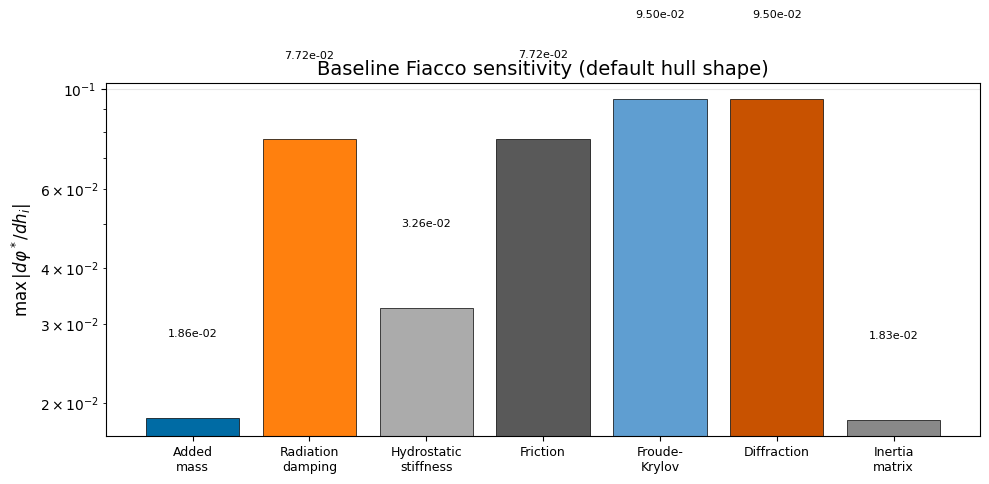

In [8]:
# Fiacco sensitivity at baseline
grad_base = sensitivity(wec_base, res_base, waves)

plot_sensitivity_bars(
    grad_base,
    title='Baseline Fiacco sensitivity (default hull shape)',
    metric='max_abs', colors=cc,
)
plt.show()

## 3. Shape-to-BEM Pipeline

We define a function that takes shape parameters $\theta = (r_1, T_1)$ and returns:
1. A solved `WEC_IPOPT` with Lagrange multipliers
2. The optimal power $\varphi^*(\theta)$ and hull volume $V(\theta)$
3. The Fiacco sensitivity $d\varphi^*/dh$

This is the "inner loop" — for each shape evaluation, we:
1. **Mesh** the hull (pygmsh)
2. **Run BEM** (Capytaine) → hydrodynamic coefficients $h$
3. **Solve IPOPT** → optimal power $\varphi^*$ and multipliers $\lambda^*$
4. **Fiacco VJP** → $d\varphi^*/dh$ (analytical, essentially free)

In [9]:
def evaluate_shape(theta, warm_start=None, verbose=False):
    """Full pipeline: shape params -> (power, volume, Fiacco grad, solve result).

    Parameters
    ----------
    theta : dict
        Shape parameters, e.g. {'r1': 1.1, 'T1': 1.5}.
    warm_start : ndarray or None
        Previous solution for warm-starting IPOPT.
    verbose : bool
        Print progress.

    Returns
    -------
    phi : float
        Optimal average electrical power [W].
    vol : float
        Hull volume [m^3].
    grad_h : BEMParams
        Fiacco sensitivity d(phi*)/d(BEM).
    res : OptimizeResult
        IPOPT result (for warm-starting next call).
    wec : WEC_IPOPT
        The WEC object.
    """
    r1 = theta['r1']
    T1 = theta['T1']

    if verbose:
        print(f'  Evaluating shape: r1={r1:.4f}, T1={T1:.4f} ... ', end='')

    wec, bem_data, displacement = build_wec_from_shape(r1, T1)
    vol = hull_volume(r1, T1)

    kw = dict(solve_kw)
    if warm_start is not None:
        xw, xo = wec.decompose_state(warm_start)
        kw['x_wec_0'] = np.array(xw)
        kw['x_opt_0'] = np.array(xo)

    res = wec.solve(waves, pto.average_power, nstate_opt, **kw)[0]
    grad_h = sensitivity(wec, res, waves)

    if verbose:
        print(f'phi* = {res.fun/1e3:.2f} kW, V = {vol:.2f} m\u00b3, '
              f'density = {res.fun/vol:.1f} W/m\u00b3')

    return res.fun, vol, grad_h, res, wec

# Test
phi_test, vol_test, grad_test, res_test, _ = evaluate_shape(SHAPE_DEFAULTS, verbose=True)
assert abs(phi_test - phi_base) < 1.0, 'Sanity check failed'
print(f'Pipeline test passed: phi* = {phi_test/1e3:.2f} kW, V = {vol_test:.2f} m\u00b3')

  Evaluating shape: r1=1.0850, T1=1.5000 ... Info    : [  0%] Difference                                                                                  
Info    : [ 10%] Difference                                                                                  
Info    : [ 20%] Difference                                                                                  
Info    : [ 30%] Difference                                                                                  
Info    : [ 40%] Difference                                                                                  
Info    : [ 50%] Difference                                                                                  
Info    : [ 60%] Difference                                                                                  
Info    : [ 70%] Difference - Filling splits of edges                                                                                
Info    : [ 80%] Difference - Making faces         

/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'influenced_dof' ('influenced_dof',) The recommendation is to set join explicitly for this case.
  total_mass_xr = xr.merge([rigid_inertia_matrix_xr, other_dofs_inertia_matrix_xr], compat="override").inertia_matrix
/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'radiating_dof' ('radiating_d

[14:12:03] WARNING  center_of_mass already defined as [0, 0, 0].

           WARNING  rotation_center already defined as [0, 0, 0].

           WARNING  FloatingBody has no inertia_matrix field. The FloatingBody mass is defined and will be used for
                    calculating the inertia matrix.

...

           WARNING  Mesh resolution for 4 problems:                                                                
                    The resolution of the mesh might be insufficient for omega ranging from 6.786 to 7.540.        
                    This warning appears when the largest panel of this mesh has radius > wavelength/8.

Output()

/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/io/xarray.py:428: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dataset = xr.merge([dataset, diffraction_cases])
/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/io/xarray.py:428: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dataset = xr.merge([d

[14:12:15] WARNING  Linear damping for DOF "Heave" has negative or close to zero terms. Shifting up damping terms  
                    [9] to a minimum of 1e-06 N/(m/s)

phi* = -1.58 kW, V = 7.08 m³, density = -222.9 W/m³
Pipeline test passed: phi* = -1.58 kW, V = 7.08 m³


## 4. Total Derivative

The outer objective is power density $J(\theta) = \varphi^*(\theta) / V(\theta)$.

We need $d\varphi^*/d\theta$, but Capytaine is not differentiable. We decompose via the chain rule:

$$\frac{d\varphi^*}{d\theta_j}
= \sum_i \frac{d\varphi^*}{dh_i} \cdot \frac{dh_i}{d\theta_j}$$

- $d\varphi^*/dh$ is the **Fiacco sensitivity** (one VJP, already computed)
- $dh/d\theta_j$ is estimated via **central finite differences** through Capytaine

Then the power density gradient follows from the **quotient rule**:

$$\frac{dJ}{d\theta_j} = \frac{1}{V}\frac{d\varphi^*}{d\theta_j}
- \frac{\varphi^*}{V^2}\frac{dV}{d\theta_j}$$

where $dV/d\theta$ is computed analytically from the hull geometry.

In [10]:
def bem_from_shape(theta):
    """Shape params → BEM coefficients (as BEMParams namedtuple).

    This runs Capytaine but does NOT solve the IPOPT problem.
    """
    hull = wot.geom.AquaHarmonics(r1=theta['r1'], T1=theta['T1'], **FIXED_GEOM)
    mesh = hull.mesh(mesh_size_factor=0.25)
    mesh_obj = load_from_meshio(mesh, 'AquaHarmonics')
    lid_mesh = mesh_obj.generate_lid(-5e-2)
    fb = cpy.FloatingBody(mesh=mesh_obj, lid_mesh=lid_mesh, name="AquaHarmonics")
    fb.add_translation_dof(name="Heave")
    fb.center_of_mass = [0, 0, 0]
    fb.rotation_center = fb.center_of_mass
    fb.mass = np.atleast_2d(5e3)

    bem_data = wot.run_bem(fb, freq, rho=rho, g=g_acc)
    hydro = wot.add_linear_friction(bem_data, friction=None)
    hydro = wot.check_radiation_damping(hydro)
    return extract_bem_params(hydro)


def hybrid_gradient(theta, grad_h, eps=1e-3):
    """Compute d(phi*)/d(theta) via chain rule.

    Parameters
    ----------
    theta : dict
        Current shape parameters.
    grad_h : BEMParams
        Fiacco sensitivity d(phi*)/d(BEM) at current shape.
    eps : float
        Finite difference step size (relative to parameter value).

    Returns
    -------
    grad_theta : dict
        Gradient d(phi*)/d(theta_j) for each shape parameter.
    """
    bp_0 = bem_from_shape(theta)
    grad_theta = {}

    for param_name in SHAPE_NAMES:
        val = theta[param_name]
        delta = eps * max(abs(val), 0.1)

        # Perturbed shapes
        theta_plus = dict(theta)
        theta_plus[param_name] = val + delta
        theta_minus = dict(theta)
        theta_minus[param_name] = val - delta

        # BEM at perturbed shapes
        bp_plus = bem_from_shape(theta_plus)
        bp_minus = bem_from_shape(theta_minus)

        # dh/d(theta_j) via central FD
        # d(phi*)/d(theta_j) = sum_i grad_h_i * dh_i/d(theta_j)
        total = 0.0
        for field in BEMParams._fields:
            dh_dtheta = (getattr(bp_plus, field) - getattr(bp_minus, field)) / (2 * delta)
            g = getattr(grad_h, field)
            # Inner product (handles real and complex)
            total += float(jnp.sum(jnp.real(g * jnp.conj(dh_dtheta))))

        grad_theta[param_name] = total

    return grad_theta

print("hybrid_gradient() defined.")
print(f"Cost per gradient: 1 IPOPT solve + {2 * len(SHAPE_NAMES)} BEM solves")

hybrid_gradient() defined.
Cost per gradient: 1 IPOPT solve + 4 BEM solves


In [11]:
# Test the hybrid gradient at baseline
grad_theta_base = hybrid_gradient(SHAPE_DEFAULTS, grad_base)

print('Hybrid gradient d(phi*)/d(theta) at baseline shape:')
for name in SHAPE_NAMES:
    print(f'  d(phi*)/d({name}) = {grad_theta_base[name]:.2f} W/m')

# Power density gradient via quotient rule
dV_base = hull_volume_gradient(SHAPE_DEFAULTS['r1'], SHAPE_DEFAULTS['T1'])
print(f'\nHull volume gradient dV/d(theta):')
for name in SHAPE_NAMES:
    print(f'  dV/d({name}) = {dV_base[name]:.4f} m\u00b3/m')

print(f'\nPower density gradient d(phi*/V)/d(theta) at baseline:')
for name in SHAPE_NAMES:
    dJ = (grad_theta_base[name] * V_base - phi_base * dV_base[name]) / V_base**2
    print(f'  d(J)/d({name}) = {dJ:.2f} W/m\u00b3/m')

Info    : [  0%] Difference                                                                                  
Info    : [ 10%] Difference                                                                                  
Info    : [ 20%] Difference                                                                                  
Info    : [ 30%] Difference                                                                                  
Info    : [ 40%] Difference                                                                                  
Info    : [ 50%] Difference                                                                                  
Info    : [ 60%] Difference                                                                                  
Info    : [ 70%] Difference - Filling splits of edges                                                                                
Info    : [ 80%] Difference - Making faces                                                      

[14:12:16] WARNING  center_of_mass already defined as [0, 0, 0].

           WARNING  rotation_center already defined as [0, 0, 0].

           WARNING  FloatingBody has no inertia_matrix field. The FloatingBody mass is defined and will be used for
                    calculating the inertia matrix.

/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'influenced_dof' ('influenced_dof',) The recommendation is to set join explicitly for this case.
  total_mass_xr = xr.merge([rigid_inertia_matrix_xr, other_dofs_inertia_matrix_xr], compat="override").inertia_matrix
/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'radiating_dof' ('radiating_d

...

           WARNING  Mesh resolution for 4 problems:                                                                
                    The resolution of the mesh might be insufficient for omega ranging from 6.786 to 7.540.        
                    This warning appears when the largest panel of this mesh has radius > wavelength/8.

Output()

/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/io/xarray.py:428: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dataset = xr.merge([dataset, diffraction_cases])
/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/io/xarray.py:428: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dataset = xr.merge([d

[14:13:17] WARNING  Linear damping for DOF "Heave" has negative or close to zero terms. Shifting up damping terms  
                    [8 9] to a minimum of 1e-06 N/(m/s)

Hybrid gradient d(phi*)/d(theta) at baseline shape:
  d(phi*)/d(r1) = -3729.97 W/m
  d(phi*)/d(T1) = 395.78 W/m

Hull volume gradient dV/d(theta):
  dV/d(r1) = 11.1832 m³/m
  dV/d(T1) = 3.6984 m³/m

Power density gradient d(phi*/V)/d(theta) at baseline:
  d(J)/d(r1) = -174.89 W/m³/m
  d(J)/d(T1) = 172.45 W/m³/m


## 5. Optimization

We use `scipy.optimize.minimize` with the L-BFGS-B algorithm (supports bounds). Each iteration:

1. `evaluate_shape(theta)` → IPOPT solve + Fiacco sensitivity
2. `hybrid_gradient(theta, grad_h)` → FD through Capytaine
3. Quotient rule → power density gradient $dJ/d\theta$

The optimizer maximizes $J(\theta) = \varphi^*(\theta)/V(\theta)$ — the electrical power per unit hull volume — encouraging compact, efficient designs.

In [12]:
# -- Optimization wrapper --
history = []

def objective_and_gradient(x):
    """Wrapper for scipy.optimize.minimize (L-BFGS-B).

    Maximizes power density J = phi* / V.

    Parameters: x = [r1, T1] as a flat numpy array.
    Returns: (-J, -dJ/dtheta) because scipy minimizes.
    """
    theta = {name: float(x[i]) for i, name in enumerate(SHAPE_NAMES)}

    # Warm-start from previous solution if available
    warm = history[-1]['res'].x if history else None

    phi, vol, grad_h, res, wec = evaluate_shape(theta, warm_start=warm, verbose=True)
    grad_theta = hybrid_gradient(theta, grad_h)
    dV = hull_volume_gradient(theta['r1'], theta['T1'])

    # Power density and its gradient (quotient rule)
    J = phi / vol
    dJ = np.array([
        (grad_theta[name] * vol - phi * dV[name]) / vol**2
        for name in SHAPE_NAMES
    ])

    history.append({
        'theta': theta, 'phi': phi, 'vol': vol, 'J': J,
        'grad': grad_theta, 'res': res,
    })

    print(f'    -> J = {J:.2f} W/m\u00b3  (phi={phi/1e3:.2f} kW, V={vol:.2f} m\u00b3)')

    # Negate: scipy minimizes, we want to maximize power density
    return -J, -dJ

# Initial point and bounds
x0 = np.array([SHAPE_DEFAULTS[name] for name in SHAPE_NAMES])
bounds = [SHAPE_BOUNDS[name] for name in SHAPE_NAMES]

print(f'Initial point: {dict(zip(SHAPE_NAMES, x0))}')
print(f'Bounds: {dict(zip(SHAPE_NAMES, bounds))}')
print(f'Baseline power density: {pd_base:.2f} W/m\u00b3')
print(f'\nStarting optimization (maximize power density)...\n')

Initial point: {'r1': np.float64(1.085), 'T1': np.float64(1.5)}
Bounds: {'r1': (0.5, 2.5), 'T1': (0.5, 3.0)}
Baseline power density: -222.89 W/m³

Starting optimization (maximize power density)...



In [13]:
result = minimize(
    objective_and_gradient,
    x0,
    method='L-BFGS-B',
    jac=True,
    bounds=bounds,
    options={
        'maxiter': 15,
        'ftol': 1e-3,
        'gtol': 1e-2,
        'disp': True,
    },
)

theta_opt = {name: float(result.x[i]) for i, name in enumerate(SHAPE_NAMES)}
J_opt = -result.fun
V_opt = hull_volume(theta_opt['r1'], theta_opt['T1'])
phi_opt = J_opt * V_opt

print(f'\n{"="*60}')
print(f'Optimization complete after {len(history)} iterations')
print(f'  Initial:  r1={SHAPE_DEFAULTS["r1"]:.3f}m, T1={SHAPE_DEFAULTS["T1"]:.3f}m')
print(f'            phi*={phi_base/1e3:.2f} kW, V={V_base:.2f} m\u00b3, J={pd_base:.2f} W/m\u00b3')
print(f'  Final:    r1={theta_opt["r1"]:.3f}m, T1={theta_opt["T1"]:.3f}m')
print(f'            phi*={phi_opt/1e3:.2f} kW, V={V_opt:.2f} m\u00b3, J={J_opt:.2f} W/m\u00b3')
print(f'  Power density improvement: {(J_opt - pd_base)/abs(pd_base)*100:.1f}%')

/var/folders/h3/jk0vk6j11bj0gsj30hhzn3lm0000gn/T/ipykernel_33625/3096575837.py:1: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


  Evaluating shape: r1=1.0850, T1=1.5000 ... Info    : [  0%] Difference                                                                                  
Info    : [ 10%] Difference                                                                                  
Info    : [ 20%] Difference                                                                                  
Info    : [ 30%] Difference                                                                                  
Info    : [ 40%] Difference                                                                                  
Info    : [ 50%] Difference                                                                                  
Info    : [ 60%] Difference                                                                                  
Info    : [ 70%] Difference - Filling splits of edges                                                                                
Info    : [ 80%] Difference - Making faces         

/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'influenced_dof' ('influenced_dof',) The recommendation is to set join explicitly for this case.
  total_mass_xr = xr.merge([rigid_inertia_matrix_xr, other_dofs_inertia_matrix_xr], compat="override").inertia_matrix
/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'radiating_dof' ('radiating_d

[14:13:18] WARNING  center_of_mass already defined as [0, 0, 0].

           WARNING  rotation_center already defined as [0, 0, 0].

...

The resolution of the mesh might be insufficient for omega ranging from 7.540 to 7.540.
This warning appears when the largest panel of this mesh has radius > wavelength/8.


           WARNING  Mesh resolution for 2 problems:                                                                
                    The resolution of the mesh might be insufficient for omega ranging from 7.540 to 7.540.        
                    This warning appears when the largest panel of this mesh has radius > wavelength/8.

Output()

    -> J = 2389.17 W/m³  (phi=3.55 kW, V=1.49 m³)

Optimization complete after 3 iterations
  Initial:  r1=1.085m, T1=1.500m
            phi*=-1.58 kW, V=7.08 m³, J=-222.89 W/m³
  Final:    r1=0.500m, T1=0.500m
            phi*=3.55 kW, V=1.49 m³, J=2389.17 W/m³
  Power density improvement: 1171.9%


/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/io/xarray.py:428: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dataset = xr.merge([dataset, diffraction_cases])
/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/io/xarray.py:428: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dataset = xr.merge([d

## 6. Results

### Convergence history

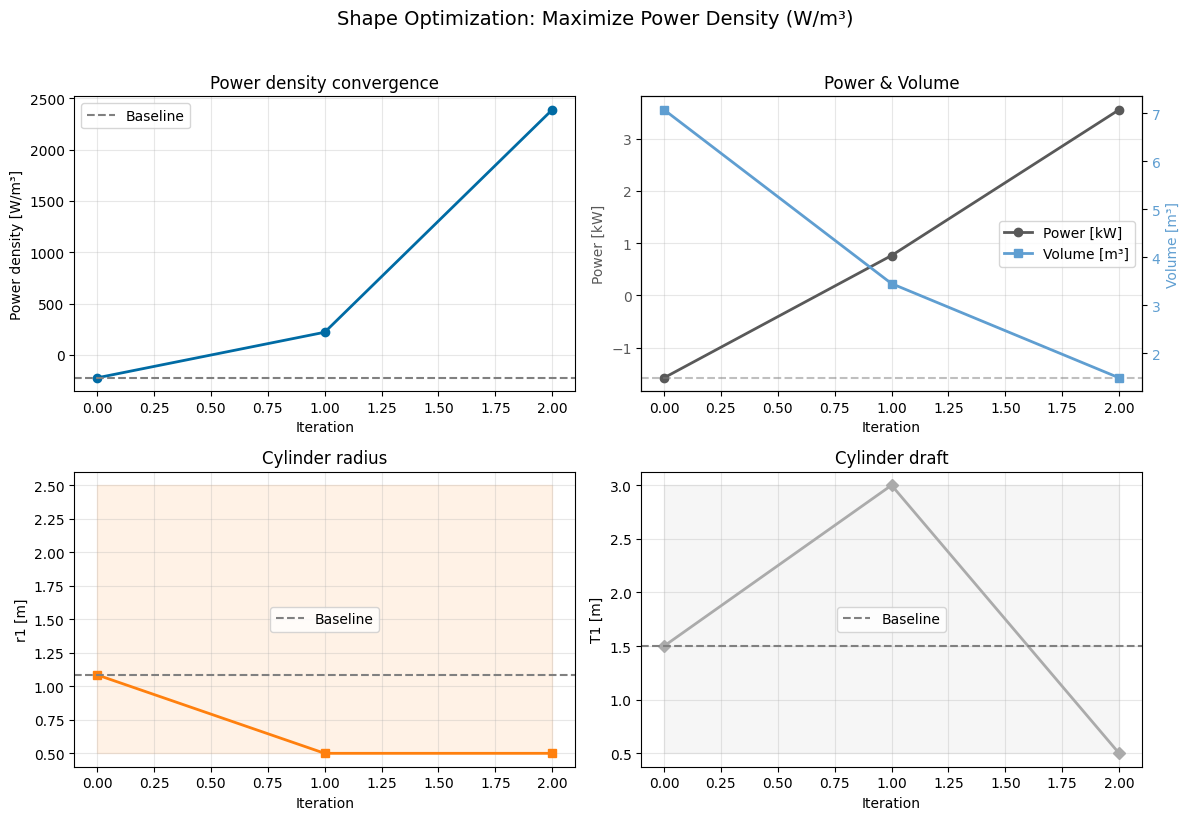

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

iters = range(len(history))
densities = [h['J'] for h in history]
powers = [h['phi'] / 1e3 for h in history]
volumes = [h['vol'] for h in history]
r1s = [h['theta']['r1'] for h in history]
T1s = [h['theta']['T1'] for h in history]

# Power density vs iteration
ax = axes[0, 0]
ax.plot(iters, densities, 'o-', color=cc[0], linewidth=2, markersize=6)
ax.axhline(pd_base, color='gray', linestyle='--', label='Baseline')
ax.set_xlabel('Iteration')
ax.set_ylabel('Power density [W/m\u00b3]')
ax.set_title('Power density convergence')
ax.legend()
ax.grid(alpha=0.3)

# Power and volume vs iteration (twin axes)
ax = axes[0, 1]
ln1 = ax.plot(iters, powers, 'o-', color=cc[3], linewidth=2, markersize=6, label='Power [kW]')
ax.axhline(phi_base / 1e3, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('Power [kW]', color=cc[3])
ax.tick_params(axis='y', labelcolor=cc[3])
ax2 = ax.twinx()
ln2 = ax2.plot(iters, volumes, 's-', color=cc[4], linewidth=2, markersize=6, label='Volume [m\u00b3]')
ax2.set_ylabel('Volume [m\u00b3]', color=cc[4])
ax2.tick_params(axis='y', labelcolor=cc[4])
lns = ln1 + ln2
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='center right')
ax.set_title('Power & Volume')
ax.grid(alpha=0.3)

# r1 vs iteration
ax = axes[1, 0]
ax.plot(iters, r1s, 's-', color=cc[1], linewidth=2, markersize=6)
ax.axhline(SHAPE_DEFAULTS['r1'], color='gray', linestyle='--', label='Baseline')
ax.fill_between(iters, SHAPE_BOUNDS['r1'][0], SHAPE_BOUNDS['r1'][1],
                alpha=0.1, color=cc[1])
ax.set_xlabel('Iteration')
ax.set_ylabel('r1 [m]')
ax.set_title('Cylinder radius')
ax.legend()
ax.grid(alpha=0.3)

# T1 vs iteration
ax = axes[1, 1]
ax.plot(iters, T1s, 'D-', color=cc[2], linewidth=2, markersize=6)
ax.axhline(SHAPE_DEFAULTS['T1'], color='gray', linestyle='--', label='Baseline')
ax.fill_between(iters, SHAPE_BOUNDS['T1'][0], SHAPE_BOUNDS['T1'][1],
                alpha=0.1, color=cc[2])
ax.set_xlabel('Iteration')
ax.set_ylabel('T1 [m]')
ax.set_title('Cylinder draft')
ax.legend()
ax.grid(alpha=0.3)

fig.suptitle('Shape Optimization: Maximize Power Density (W/m\u00b3)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Hull cross-section comparison

/var/folders/h3/jk0vk6j11bj0gsj30hhzn3lm0000gn/T/ipykernel_33625/13037145.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12)


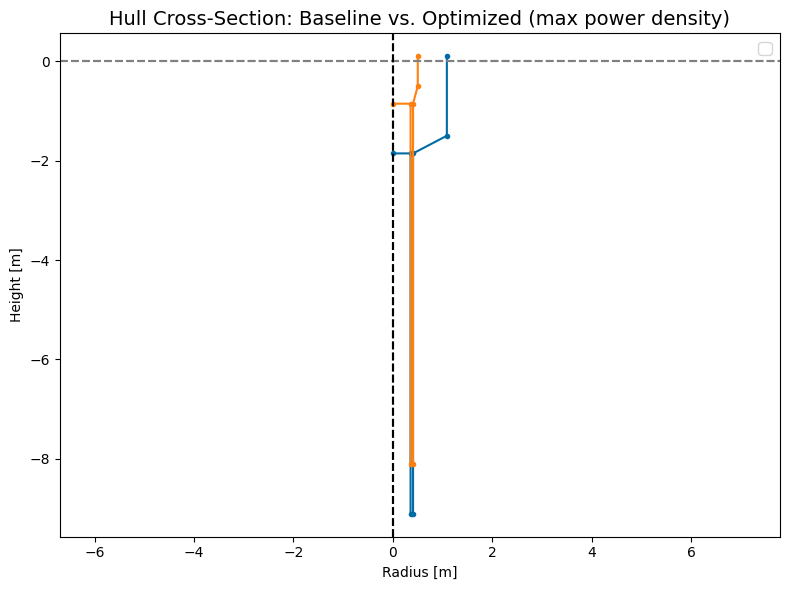


Shape comparison:
Parameter        Baseline  Optimized     Change
----------------------------------------------
r1                  1.085m      0.500m     -0.585m
T1                  1.500m      0.500m     -1.000m
Volume              7.08m³      1.49m³     -5.59m³
Power              -1.58kW      3.55kW     +5.13kW
Density          -222.9W/m³   2389.2W/m³  +2612.1W/m³


In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

# Baseline hull
hull_base = wot.geom.AquaHarmonics(**SHAPE_DEFAULTS, **FIXED_GEOM)
hull_base.plot_cross_section(ax=ax, color=cc[0], linewidth=2, label='Baseline')

# Optimized hull
hull_opt = wot.geom.AquaHarmonics(r1=theta_opt['r1'], T1=theta_opt['T1'], **FIXED_GEOM)
hull_opt.plot_cross_section(ax=ax, color=cc[1], linewidth=2, label='Optimized')

ax.legend(fontsize=12)
ax.set_title('Hull Cross-Section: Baseline vs. Optimized (max power density)', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\nShape comparison:')
print(f'{"Parameter":14s} {"Baseline":>10s} {"Optimized":>10s} {"Change":>10s}')
print(f'{"-"*46}')
for name in SHAPE_NAMES:
    v0 = SHAPE_DEFAULTS[name]
    v1 = theta_opt[name]
    print(f'{name:14s} {v0:10.3f}m {v1:10.3f}m {v1-v0:+10.3f}m')
print(f'{"Volume":14s} {V_base:9.2f}m\u00b3 {V_opt:9.2f}m\u00b3 {V_opt-V_base:+9.2f}m\u00b3')
print(f'{"Power":14s} {phi_base/1e3:9.2f}kW {phi_opt/1e3:9.2f}kW '
      f'{(phi_opt-phi_base)/1e3:+9.2f}kW')
print(f'{"Density":14s} {pd_base:8.1f}W/m\u00b3 {J_opt:8.1f}W/m\u00b3 '
      f'{J_opt-pd_base:+8.1f}W/m\u00b3')

### Sensitivity comparison: baseline vs. optimized

  Evaluating shape: r1=0.5000, T1=0.5000 ... Info    : [  0%] Difference                                                                                  
Info    : [ 10%] Difference                                                                                  
Info    : [ 20%] Difference                                                                                  
Info    : [ 30%] Difference                                                                                  
Info    : [ 40%] Difference                                                                                  
Info    : [ 50%] Difference                                                                                  
Info    : [ 60%] Difference                                                                                  
Info    : [ 70%] Difference - Filling splits of edges                                                                                
Info    : [ 80%] Difference - Making faces         

/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'influenced_dof' ('influenced_dof',) The recommendation is to set join explicitly for this case.
  total_mass_xr = xr.merge([rigid_inertia_matrix_xr, other_dofs_inertia_matrix_xr], compat="override").inertia_matrix
/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'radiating_dof' ('radiating_d

[14:16:24] WARNING  center_of_mass already defined as [0, 0, 0].

           WARNING  rotation_center already defined as [0, 0, 0].

           WARNING  FloatingBody has no inertia_matrix field. The FloatingBody mass is defined and will be used for
                    calculating the inertia matrix.

...

           WARNING  Mesh resolution for 2 problems:                                                                
                    The resolution of the mesh might be insufficient for omega ranging from 7.540 to 7.540.        
                    This warning appears when the largest panel of this mesh has radius > wavelength/8.

Output()

/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/io/xarray.py:428: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dataset = xr.merge([dataset, diffraction_cases])
/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/io/xarray.py:428: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dataset = xr.merge([d

[14:16:38] WARNING  b'Algorithm converged to a point of local infeasibility. Problem may be infeasible.'  (status  
                    2)

phi* = 3.55 kW, V = 1.49 m³, density = 2389.2 W/m³


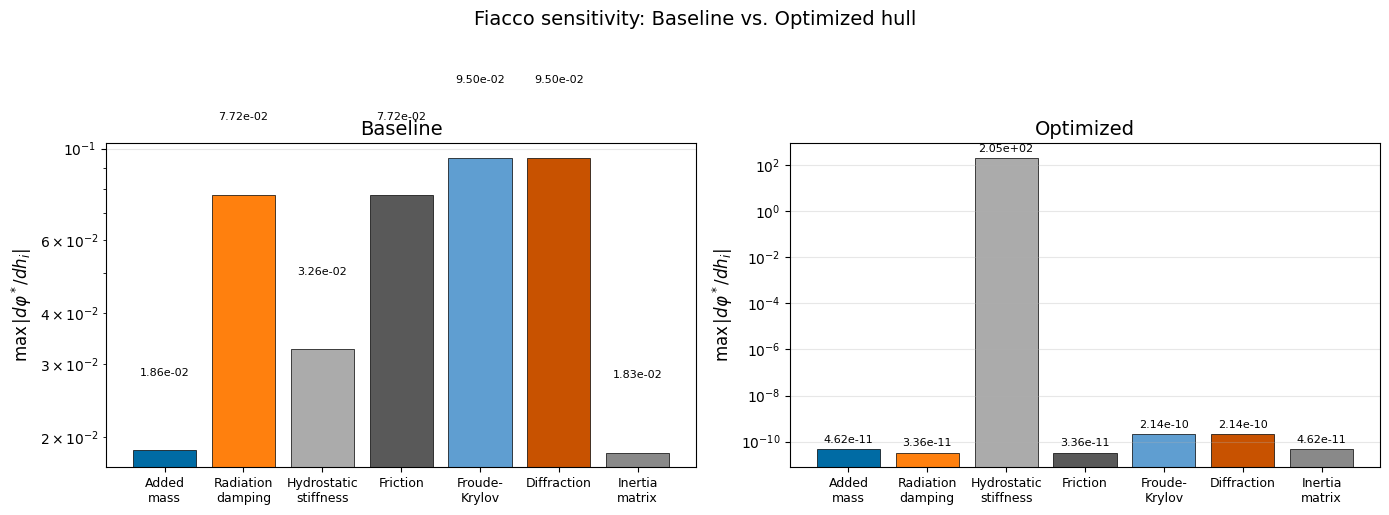

In [16]:
# Compute sensitivity at optimized shape
_, _, grad_opt, _, _ = evaluate_shape(theta_opt, verbose=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_sensitivity_bars(grad_base, title='Baseline', metric='max_abs',
                      colors=cc, ax=axes[0])
plot_sensitivity_bars(grad_opt, title='Optimized', metric='max_abs',
                      colors=cc, ax=axes[1])

fig.suptitle('Fiacco sensitivity: Baseline vs. Optimized hull', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Summary

This tutorial demonstrated **gradient-based hull shape optimization** for the AquaHarmonics WEC, maximizing **electrical power per unit hull volume** (power density, W/m³) using a hybrid approach.

### Objective

$$J(\theta) = \frac{\varphi^*(\theta)}{V(\theta)} \quad \text{[W/m\u00b3]}$$

Maximizing power density rather than raw power penalizes large hulls and encourages compact, efficient designs.

### Method
1. **Inner loop** (IPOPT): solve for optimal WEC control at each shape → $\varphi^*$
2. **Fiacco sensitivity** (analytical): compute $d\varphi^*/dh$ via one VJP — essentially free
3. **Finite differences** (Capytaine): estimate $dh/d\theta$ — only $2n_{\text{shape}}$ BEM solves
4. **Quotient rule**: $dJ/d\theta = (1/V)\,d\varphi^*/d\theta - (\varphi^*/V^2)\,dV/d\theta$
5. **Volume gradient** $dV/d\theta$: computed analytically from hull geometry (trivial)

### Key advantages
- **Much cheaper than full FD**: only BEM is finite-differenced (seconds), not the IPOPT solve (minutes)
- **Accurate gradients**: Fiacco sensitivity is exact; volume gradient is analytical
- **Scalable**: cost grows linearly with number of shape parameters
- **Physical objective**: power density penalizes oversized hulls

### Cost per optimization iteration
| Component | Cost |
|---|---|
| IPOPT solve | 1 solve (~minutes) |
| Fiacco VJP | 1 VJP (~milliseconds) |
| Volume gradient | analytical (~microseconds) |
| Capytaine FD | $2 n_{\text{shape}}$ BEM solves (~seconds each) |
| **Total** | dominated by IPOPT solve |

### Future work
- Differentiate through Capytaine (AD or adjoint) to eliminate finite differences entirely
- Optimize more shape parameters (tube dimensions, conic frustum)
- Multi-objective optimization (power density vs. structural loads)
- Multiple wave conditions (sea states)